## Extract Rare Disease

### Setup

In [1]:
%store -r sampled_data

In [2]:
from IPython.display import Image, display

In [3]:
import argparse
import json
import os
import torch
import traceback
import numpy as np
from datetime import datetime
from typing import Dict, List, Any
from pathlib import Path
from tqdm import tqdm
from argparse import Namespace

# Set correct directory pathing
import os
import sys

# Import project modules
sys.path.insert(0, '/Users/williampang/Desktop/Coding_Stuff/rare_disease_pyHealth/RDMA')
from rdma.rdrag.entity import LLMRDExtractor, RetrievalEnhancedRDExtractor,MultiIterativeRDExtractor,IterativeLLMRDExtractor
from rdma.utils.embedding import EmbeddingsManager
from rdma.hporag.context import ContextExtractor
from rdma.utils.llm_client import LocalLLMClient, APILLMClient
from rdma.utils.setup import setup_device
from dotenv import load_dotenv

load_dotenv()

/Users/williampang/Desktop/Coding_Stuff/rare_disease_pyHealth/.venv/lib/python3.12/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


True

In [4]:
args = Namespace(
      llm_type="api",
      api_config="api_config.json"
  )

In [5]:
def initialize_llm_client(args: argparse.Namespace):
    """Initialize appropriate LLM client based on arguments."""
    if args.llm_type == "api":
        if args.api_config:
            return APILLMClient.from_config(args.api_config)
        else:
            return APILLMClient.initialize_from_input()
    else:  # local
        return LocalLLMClient(
            model_type=args.model_type,
            device=device,
            cache_dir=args.cache_dir,
            temperature=args.temperature
        )

def load_input_data(data) -> Dict[str, Dict]:
    """Load and validate the input JSON file."""
    try:
        
        # Validate structure
        if not isinstance(data, dict):
            raise ValueError(f"Input file {input_file} must contain a JSON object mapping IDs to clinical notes")
        
        processed_data = {}
        for doc_id, doc_data in data.items():
            # Check if this is MIMIC format
            if isinstance(doc_data, dict) and 'note_details' in doc_data:
                note_details = doc_data['note_details']
                # Extract clinical text
                clinical_text = note_details.get('text', '')
                if clinical_text:
                    processed_data[doc_id] = {
                        'clinical_text': clinical_text,
                        'patient_id': note_details.get('subject_id', ''),
                        'admission_id': note_details.get('hadm_id', ''),
                        'category': note_details.get('category', ''),
                        'chart_date': note_details.get('chartdate', '')
                    }
            else:
                # Fallback to simpler format
                if isinstance(doc_data, dict) and 'clinical_text' in doc_data:
                    processed_data[doc_id] = doc_data
                elif isinstance(doc_data, str):
                    # Assume the string itself is the clinical text
                    processed_data[doc_id] = {
                        'clinical_text': doc_data
                    }
        
        if not processed_data:
            raise ValueError(f"No valid clinical notes found in {input_file}")
        
        return processed_data
    
    except (json.JSONDecodeError, ValueError) as e:
        timestamp_print(f"Error loading input file: {e}")
        raise

In [6]:
llm_client = initialize_llm_client(args)

# try:
# response = llm_client.query(
#       user_input="What is dermatitis?",
#       system_message="You are a medical expert specializing in rare diseases."
#   )
# print(response)

In [7]:
entity_extractor = LLMRDExtractor(
      llm_client=llm_client,
      system_message="You are a medical expert specializing in rare diseases."
  )

context_extractor = ContextExtractor()

In [8]:
notes_json_data = load_input_data(sampled_data)

### LLM Only Disease Identification

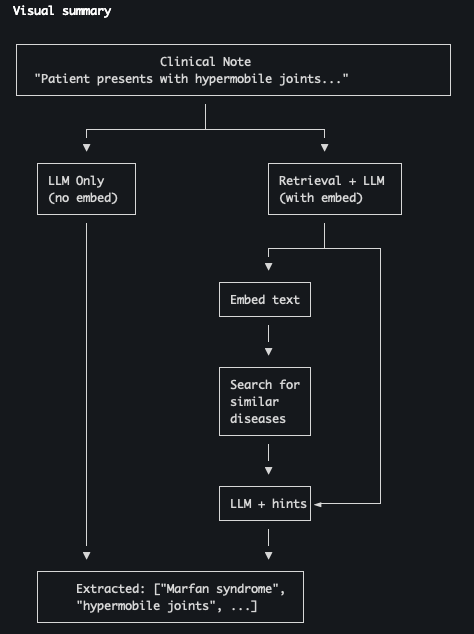

In [9]:
display(Image('images/general_pipeline.png'))

In [10]:
results = {}
for i, (case_id, case_data) in enumerate(tqdm(list(notes_json_data.items()), desc="Processing cases")):
    entities = entity_extractor.extract_entities(case_data.get("clinical_text"))
    entity_contexts = context_extractor.extract_contexts(entities, case_data.get("clinical_text"), window_size=0)
    results[case_id] = {
                "clinical_text": case_data.get("clinical_text"),
                "entities_with_contexts": entity_contexts,
                "metadata": {
                    "patient_id": case_data.get("patient_id", ""),
                    "admission_id": case_data.get("admission_id", ""),
                    "category": case_data.get("category", ""),
                    "chart_date": case_data.get("chart_date", "")
                }
            }

Processing cases:   0%|                                                                                                                | 0/5 [00:00<?, ?it/s]

TOTAL_TOKENS_USED before query: 0


Processing cases:  20%|████████████████████▊                                                                                   | 1/5 [00:00<00:03,  1.02it/s]

TOTAL_TOKENS_USED before query: 3942


Processing cases:  40%|█████████████████████████████████████████▌                                                              | 2/5 [00:01<00:02,  1.23it/s]

...

Processing cases:  60%|██████████████████████████████████████████████████████████████▍                                         | 3/5 [00:02<00:01,  1.46it/s]

TOTAL_TOKENS_USED before query: 12007


Processing cases:  80%|███████████████████████████████████████████████████████████████████████████████████▏                    | 4/5 [00:03<00:00,  1.37it/s]

TOTAL_TOKENS_USED before query: 16082


Processing cases: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.34it/s]


### Retrieval Enhanced Extractor

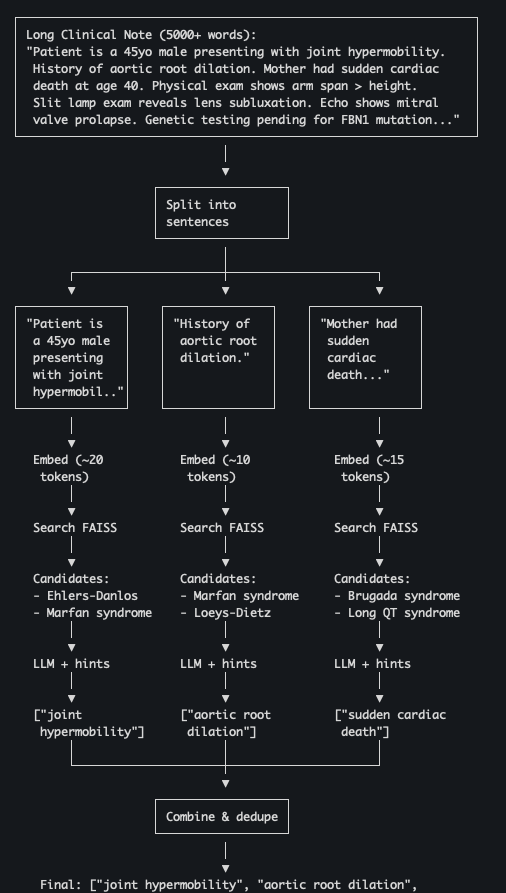

In [11]:
display(Image('images/retrieval_enhanced_extractor.png'))

In [ ]:
%store results